# Housing Prices – Prediction
Complete Pipeline: EDA → Feature Analysis → Cleaning → Model Comparison → Evaluation

## 0 · Imports & Setup

In [24]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
DATA_PATH = 'housing prices/Housing.csv'
print('All packages loaded ✓')

All packages loaded ✓


## 1 · Load Data & First Overview (EDA)

In [25]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [26]:
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Missing Values ===')
print(df.isnull().sum())
print(f'\n=== Duplicates: {df.duplicated().sum()}')

=== Data Types ===
price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

=== Missing Values ===
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

=== Duplicates: 0


In [27]:
df.describe(include='all')

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


In [28]:
# Cardinality of categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f'{col}: {df[col].unique()}')

mainroad: <StringArray>
['yes', 'no']
Length: 2, dtype: str
guestroom: <StringArray>
['no', 'yes']
Length: 2, dtype: str
basement: <StringArray>
['no', 'yes']
Length: 2, dtype: str
hotwaterheating: <StringArray>
['no', 'yes']
Length: 2, dtype: str
airconditioning: <StringArray>
['yes', 'no']
Length: 2, dtype: str
prefarea: <StringArray>
['yes', 'no']
Length: 2, dtype: str
furnishingstatus: <StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str


## 2 · Feature Visualization

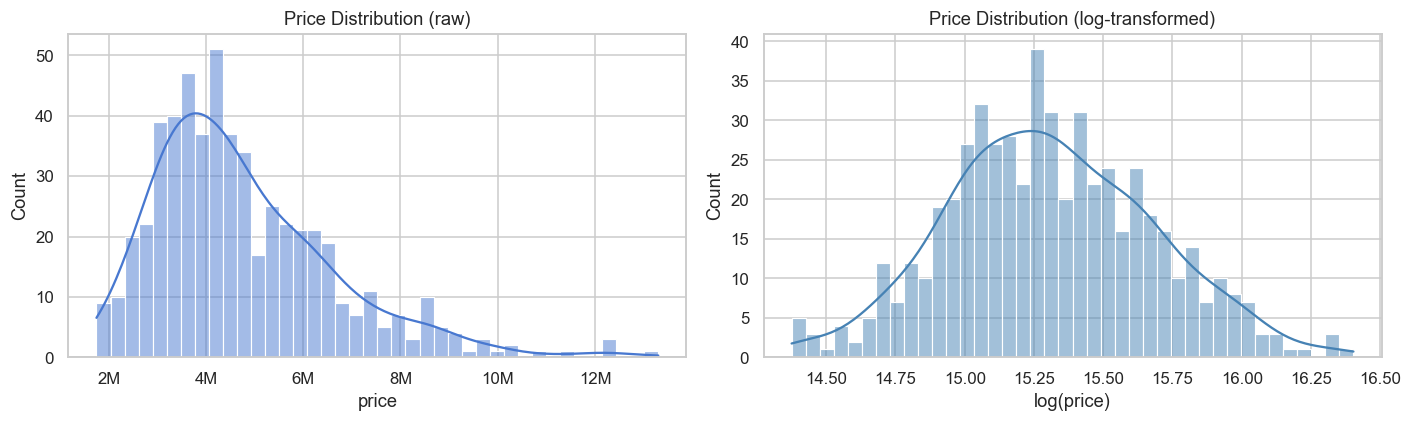

In [29]:
# Target variable: price distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df['price'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Price Distribution (raw)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

sns.histplot(np.log1p(df['price']), bins=40, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Price Distribution (log-transformed)')
axes[1].set_xlabel('log(price)')

plt.tight_layout()
plt.show()

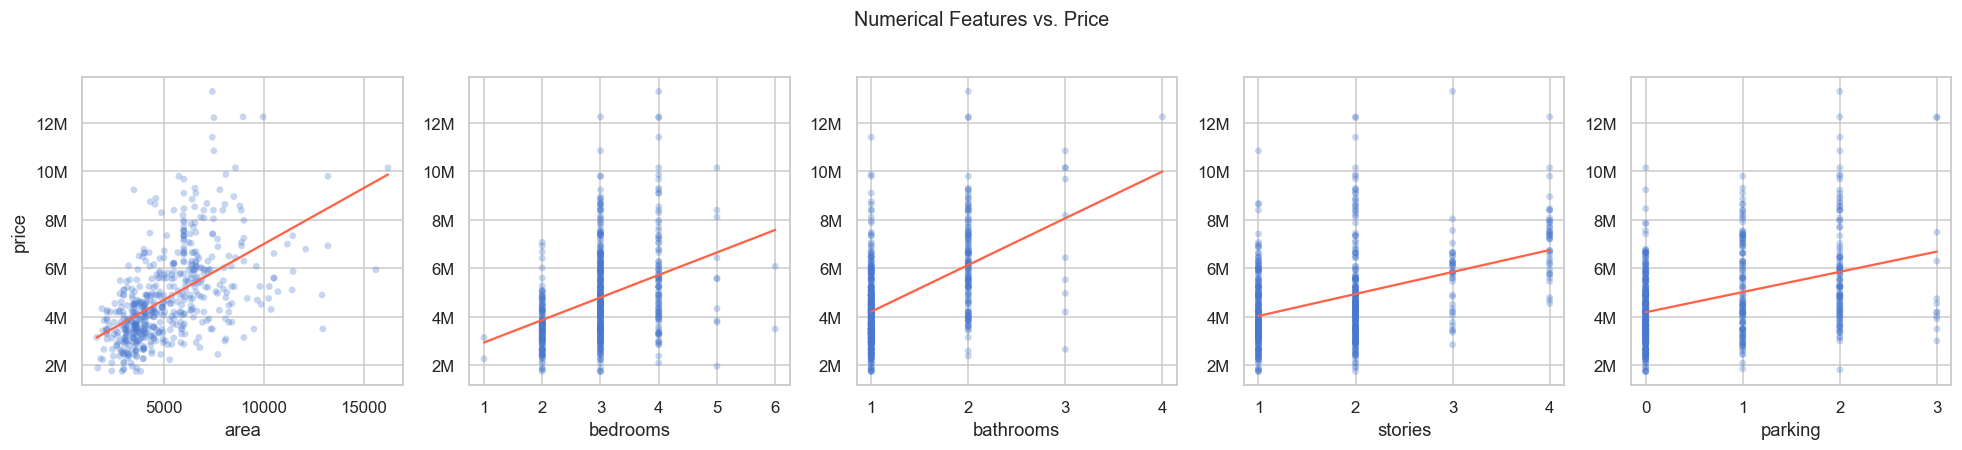

In [30]:
# Numerical features vs. price
num_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

fig, axes = plt.subplots(1, len(num_features), figsize=(18, 4))
for ax, feat in zip(axes, num_features):
    ax.scatter(df[feat], df['price'], alpha=0.3, edgecolors='none', s=20)
    ax.set_xlabel(feat)
    ax.set_ylabel('price' if ax == axes[0] else '')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
    
    # Trend line
    m, b = np.polyfit(df[feat], df['price'], 1)
    ax.plot(sorted(df[feat]), [m*x+b for x in sorted(df[feat])], color='tomato', linewidth=1.5)

plt.suptitle('Numerical Features vs. Price', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

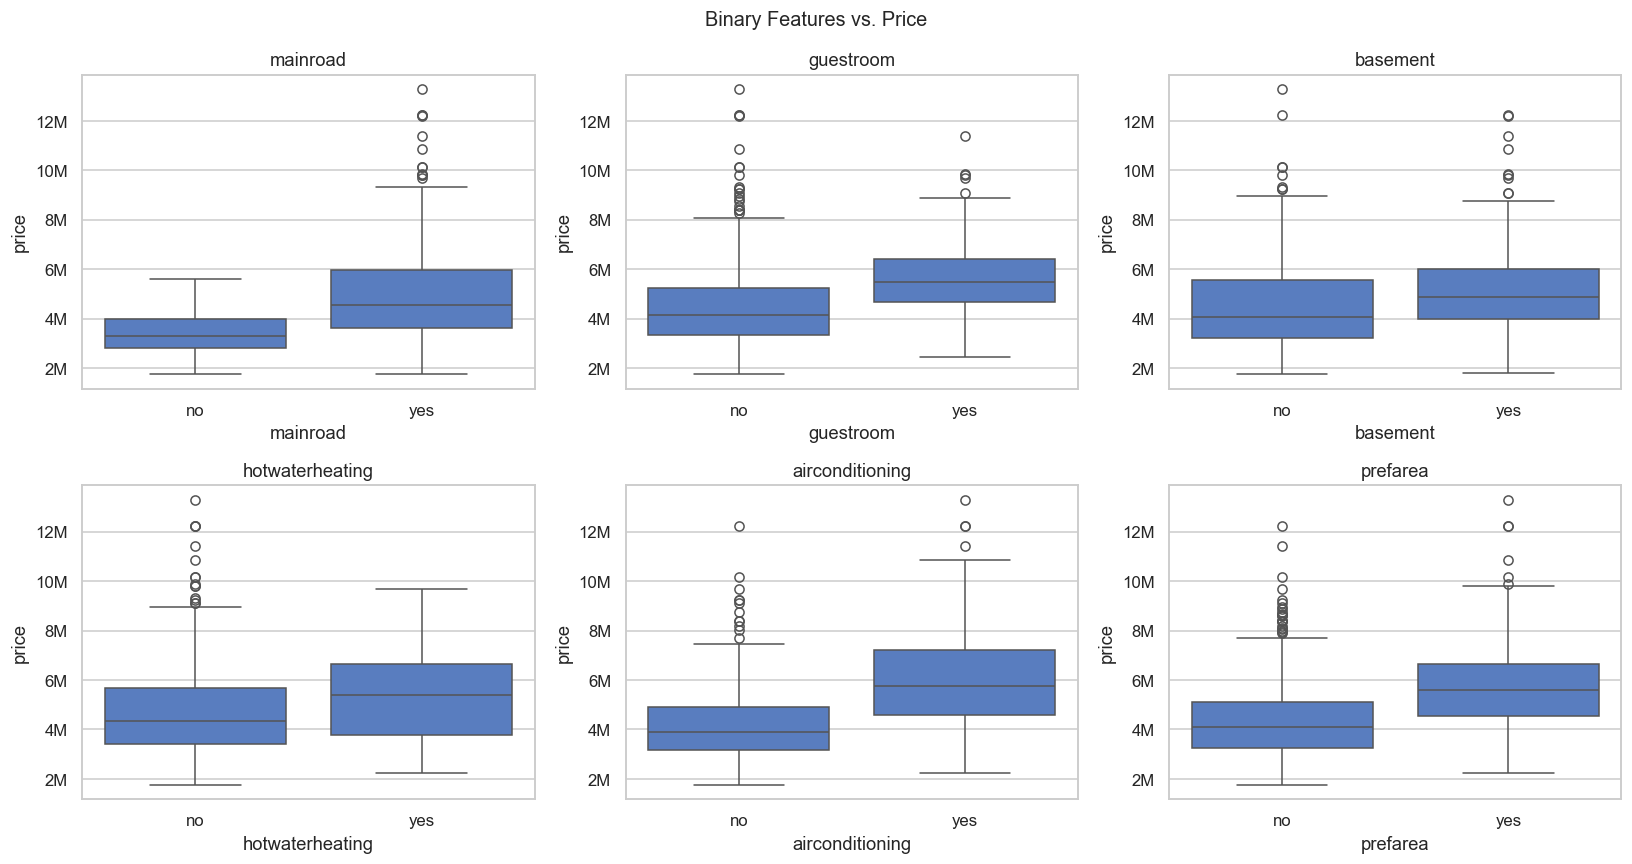

In [31]:
# Binary yes/no features – Boxplots
binary_features = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feat in zip(axes, binary_features):
    sns.boxplot(x=feat, y='price', data=df, ax=ax, order=['no', 'yes'])
    ax.set_title(feat)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.suptitle('Binary Features vs. Price', fontsize=13)
plt.tight_layout()
plt.show()

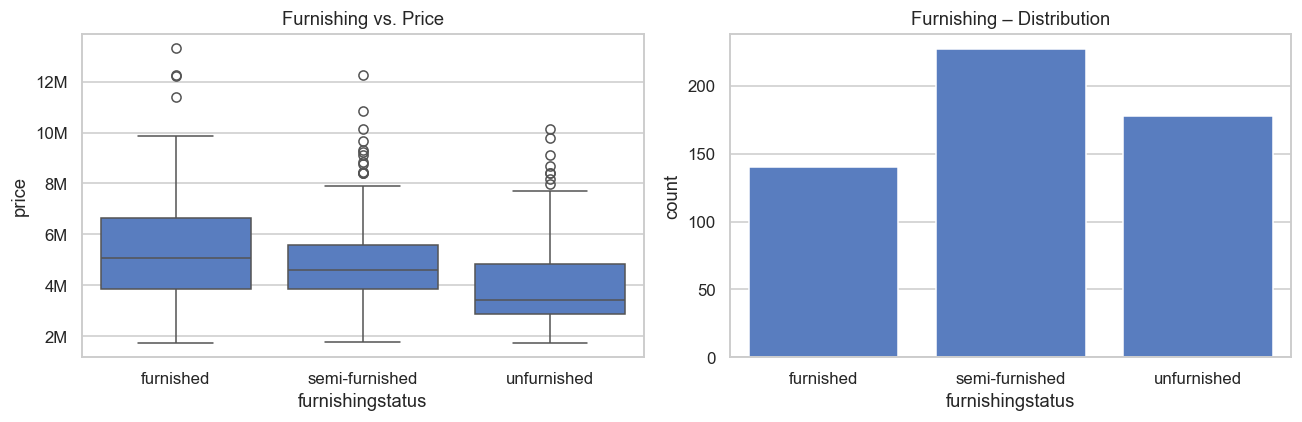

In [32]:
# Furnishing Status
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order = ['furnished', 'semi-furnished', 'unfurnished']
sns.boxplot(x='furnishingstatus', y='price', data=df, order=order, ax=axes[0])
axes[0].set_title('Furnishing vs. Price')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

sns.countplot(x='furnishingstatus', data=df, order=order, ax=axes[1])
axes[1].set_title('Furnishing – Distribution')

plt.tight_layout()
plt.show()

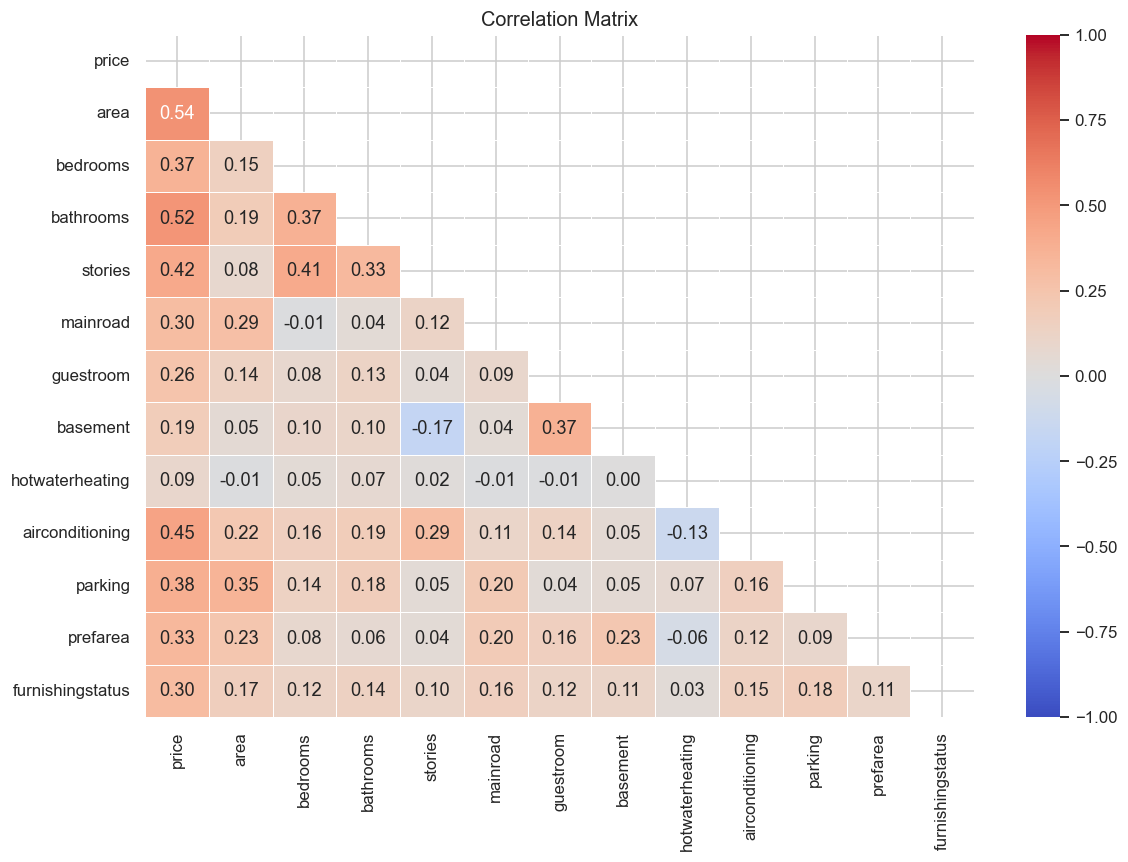

In [33]:
# Correlation heatmap (after numerical encoding)
df_num = df.copy()
yes_no_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in yes_no_cols:
    df_num[col] = (df_num[col] == 'yes').astype(int)

furnish_map = {'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0}
df_num['furnishingstatus'] = df_num['furnishingstatus'].map(furnish_map)

corr = df_num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## 3 · Feature Improvement – Selection & Evaluation

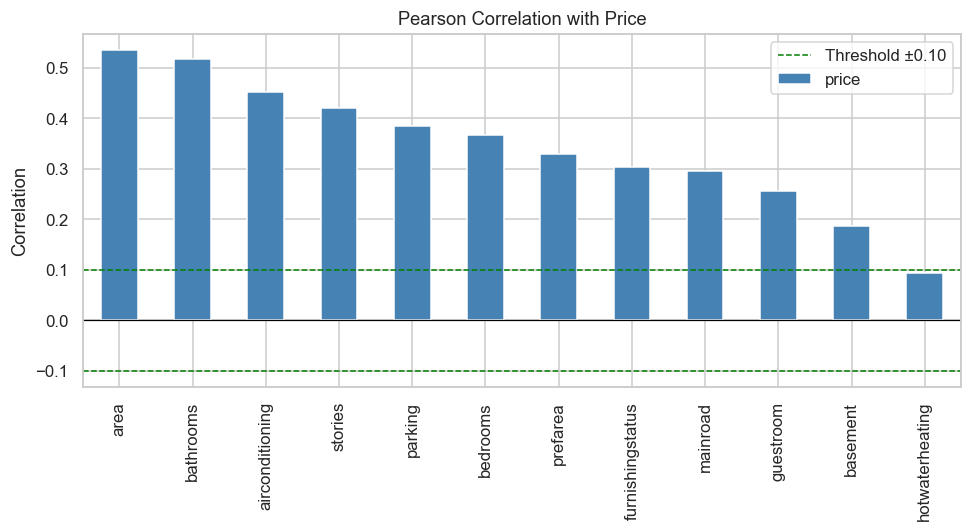


Correlation values:
area                0.536
bathrooms           0.518
airconditioning     0.453
stories             0.421
parking             0.384
bedrooms            0.366
prefarea            0.330
furnishingstatus    0.305
mainroad            0.297
guestroom           0.256
basement            0.187
hotwaterheating     0.093


In [34]:
# Correlation with target feature sorted by absolute value
price_corr = corr['price'].drop('price').sort_values(key=abs, ascending=False)

plt.figure(figsize=(9, 5))
colors = ['tomato' if v < 0 else 'steelblue' for v in price_corr]
price_corr.plot(kind='bar', color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline(0.1, color='green', linewidth=1, linestyle='--', label='Threshold ±0.10')
plt.axhline(-0.1, color='green', linewidth=1, linestyle='--')
plt.title('Pearson Correlation with Price')
plt.ylabel('Correlation')
plt.legend()
plt.tight_layout()
plt.show()

print('\nCorrelation values:')
print(price_corr.round(3).to_string())

In [35]:
# 'hotwaterheating' has very low correlation and a strongly imbalanced distribution
print('hotwaterheating distribution:')
print(df['hotwaterheating'].value_counts())
print(f'\nCorrelation with price: {price_corr["hotwaterheating"]:.3f}')
print('\n→ hotwaterheating removed (>95 % "no", correlation near 0)')

hotwaterheating distribution:
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

Correlation with price: 0.093

→ hotwaterheating removed (>95 % "no", correlation near 0)


## 4 · Data Cleaning & Encoding

In [36]:
df_clean = df.copy()

# Drop feature
df_clean.drop(columns=['hotwaterheating'], inplace=True)

# Binary encoding: yes → 1, no → 0
binary_cols = ['mainroad', 'guestroom', 'basement', 'airconditioning', 'prefarea']
for col in binary_cols:
    df_clean[col] = (df_clean[col] == 'yes').astype(int)

# Ordinal encoding: furnished > semi-furnished > unfurnished
df_clean['furnishingstatus'] = df_clean['furnishingstatus'].map(furnish_map)

print('Encoding complete.')
df_clean.head()

Encoding complete.


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,1,2,0,2


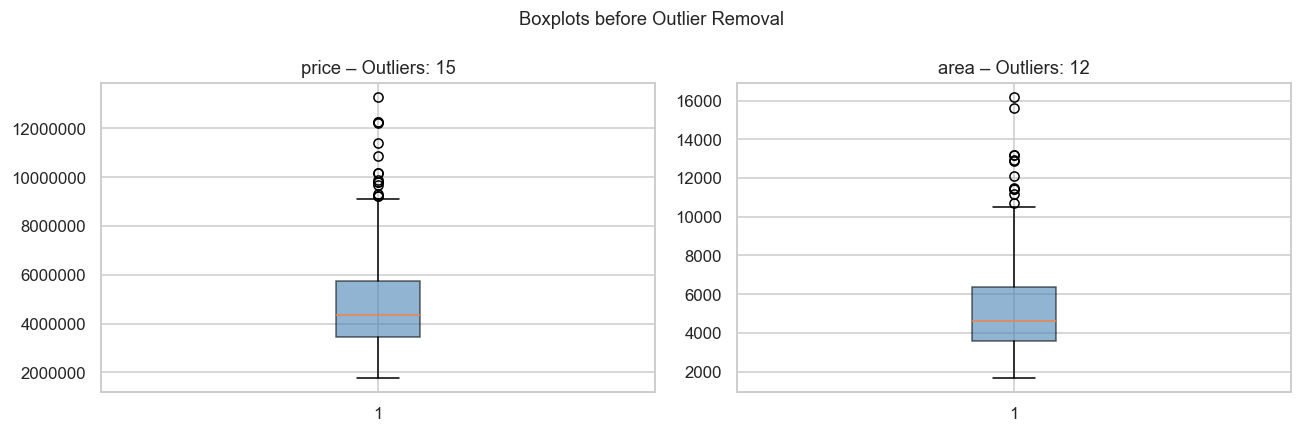

In [37]:
# Outlier detection via IQR on target variable and 'area'
def iqr_bounds(series, factor=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['price', 'area']):
    lo, hi = iqr_bounds(df_clean[col])
    outliers = df_clean[(df_clean[col] < lo) | (df_clean[col] > hi)]
    ax.boxplot(df_clean[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(f'{col} – Outliers: {len(outliers)}')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.1f}M' if col == 'price' else f'{x:.0f}'))

plt.suptitle('Boxplots before Outlier Removal', fontsize=12)
plt.tight_layout()
plt.show()

In [38]:
n_before = len(df_clean)

# Remove outliers only for 'area' (price outliers are part of the market)
lo_area, hi_area = iqr_bounds(df_clean['area'])
df_clean = df_clean[(df_clean['area'] >= lo_area) & (df_clean['area'] <= hi_area)]

print(f'Rows before cleaning : {n_before}')
print(f'Rows after cleaning  : {len(df_clean)}')
print(f'Removed outliers     : {n_before - len(df_clean)}')

df_clean.reset_index(drop=True, inplace=True)

Rows before cleaning : 545
Rows after cleaning  : 533
Removed outliers     : 12


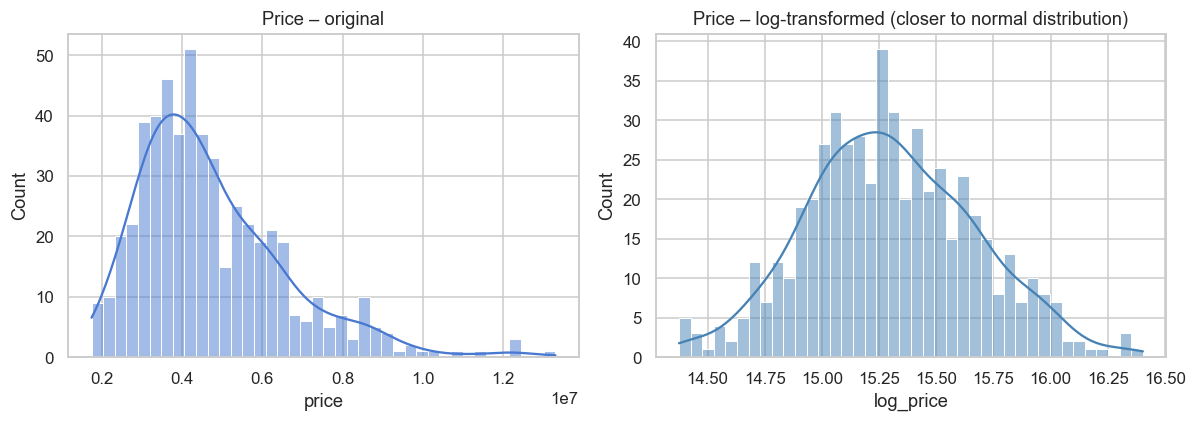

In [39]:
# Log-transformation of target variable (right-skewed)
df_clean['log_price'] = np.log1p(df_clean['price'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df_clean['price'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Price – original')
sns.histplot(df_clean['log_price'], bins=40, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Price – log-transformed (closer to normal distribution)')
plt.tight_layout()
plt.show()

## 5 · Model Comparison

In [40]:
FEATURE_COLS = [c for c in df_clean.columns if c not in ['price', 'log_price']]
X = df_clean[FEATURE_COLS]
y = df_clean['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

# Scaling for linear models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train set: {X_train.shape[0]} | Test set: {X_test.shape[0]}')
print(f'Features : {FEATURE_COLS}')

Train set: 426 | Test set: 107
Features : ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [41]:
models = {
    'Linear Regression' : (LinearRegression(),           X_train_sc, X_test_sc),
    'Ridge'             : (Ridge(alpha=1.0),              X_train_sc, X_test_sc),
    'Lasso'             : (Lasso(alpha=0.001),            X_train_sc, X_test_sc),
    'Decision Tree'     : (DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE), X_train, X_test),
    'Random Forest'     : (RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE), X_train, X_test),
    'Gradient Boosting' : (GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=RANDOM_STATE), X_train, X_test),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    y_pred  = model.predict(Xte)
    cv_r2   = cross_val_score(model, Xtr, y_train, cv=cv, scoring='r2')
    
    # Metrics on original price scale
    price_true = np.expm1(y_test)
    price_pred = np.expm1(y_pred)
    
    results.append({
        'Model'    : name,
        'R² Test'  : r2_score(y_test, y_pred),
        'CV R² ∅'  : cv_r2.mean(),
        'CV R² σ'  : cv_r2.std(),
        'MAE (Mln)': mean_absolute_error(price_true, price_pred) / 1e6,
        'RMSE (Mln)': np.sqrt(mean_squared_error(price_true, price_pred)) / 1e6,
    })

results_df = pd.DataFrame(results).sort_values('R² Test', ascending=False)
results_df.style.format({
    'R² Test': '{:.3f}', 'CV R² ∅': '{:.3f}', 'CV R² σ': '{:.3f}',
    'MAE (Mln)': '{:.3f}', 'RMSE (Mln)': '{:.3f}'
}).background_gradient(subset=['R² Test', 'CV R² ∅'], cmap='RdYlGn')

,Model,R² Test,CV R² ∅,CV R² σ,MAE (Mln),RMSE (Mln)
1,Ridge,0.629,0.663,0.048,0.942,1.376
0,Linear Regression,0.629,0.663,0.048,0.942,1.376
2,Lasso,0.628,0.663,0.047,0.942,1.378
5,Gradient Boosting,0.598,0.638,0.037,0.917,1.452
4,Random Forest,0.585,0.629,0.033,0.973,1.495
3,Decision Tree,0.492,0.422,0.056,1.095,1.577


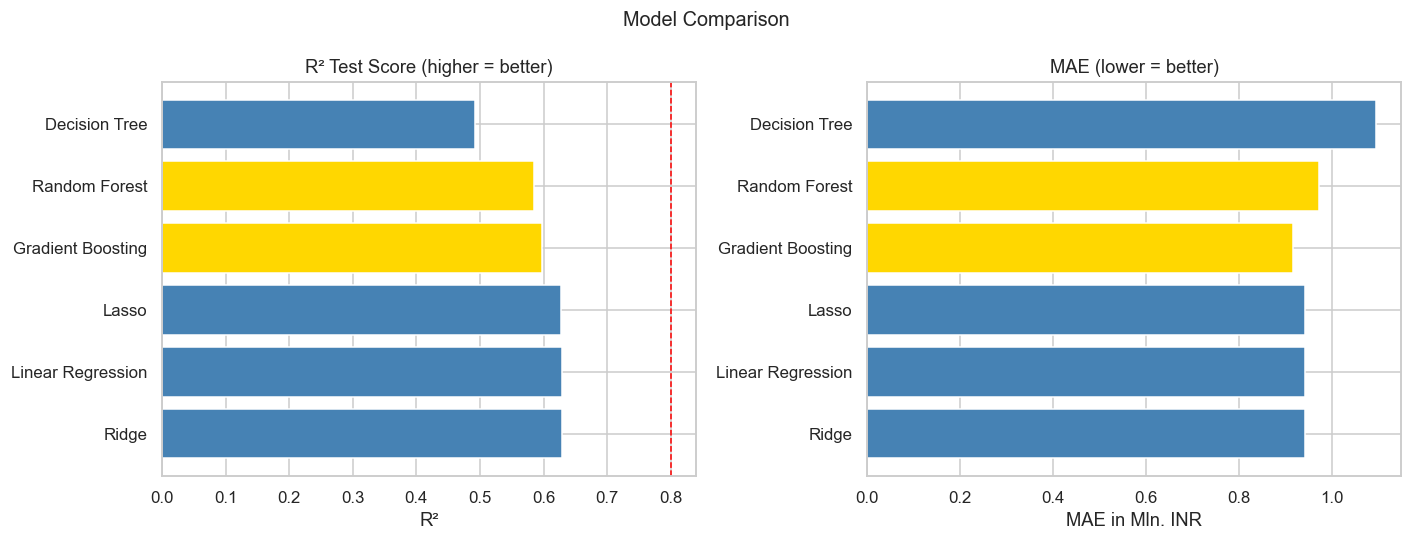

In [42]:
# Model comparison – bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

r2_vals  = results_df['R² Test'].values
mae_vals = results_df['MAE (Mln)'].values
names    = results_df['Model'].values
colors   = ['gold' if n in ['Gradient Boosting', 'Random Forest'] else 'steelblue' for n in names]

axes[0].barh(names, r2_vals, color=colors)
axes[0].set_xlabel('R²')
axes[0].set_title('R² Test Score (higher = better)')
axes[0].axvline(0.8, color='red', linestyle='--', linewidth=1)

axes[1].barh(names, mae_vals, color=colors)
axes[1].set_xlabel('MAE in Mln. INR')
axes[1].set_title('MAE (lower = better)')

plt.suptitle('Model Comparison', fontsize=13)
plt.tight_layout()
plt.show()

## 6 · Best Model – Results & Interpretation

In [43]:
# Gradient Boosting as best model
best_name  = 'Gradient Boosting'
best_model, Xtr_best, Xte_best = models[best_name]

y_pred_best  = best_model.predict(Xte_best)
price_true   = np.expm1(y_test.values)
price_pred   = np.expm1(y_pred_best)
residuals    = price_true - price_pred

print(f'=== {best_name} – Test Set ===')
print(f'R²  : {r2_score(y_test, y_pred_best):.4f}')
print(f'MAE : {mean_absolute_error(price_true, price_pred)/1e6:.4f} Mln. INR')
print(f'RMSE: {np.sqrt(mean_squared_error(price_true, price_pred))/1e6:.4f} Mln. INR')

=== Gradient Boosting – Test Set ===
R²  : 0.5981
MAE : 0.9166 Mln. INR
RMSE: 1.4517 Mln. INR


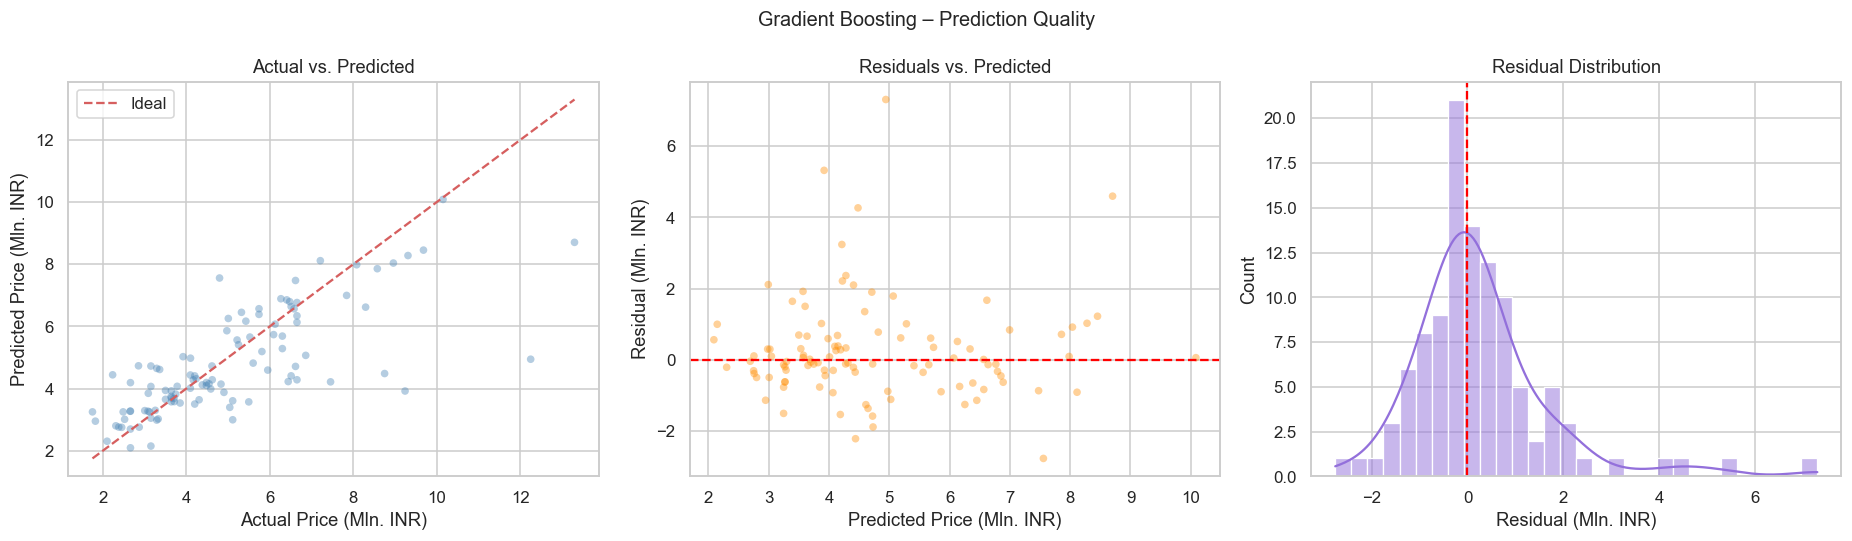

In [44]:
# Actual vs. Predicted
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# — Scatter: actual vs. predicted
ax = axes[0]
ax.scatter(price_true/1e6, price_pred/1e6, alpha=0.4, edgecolors='none', s=25, color='steelblue')
mn, mx = price_true.min()/1e6, price_true.max()/1e6
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Ideal')
ax.set_xlabel('Actual Price (Mln. INR)')
ax.set_ylabel('Predicted Price (Mln. INR)')
ax.set_title('Actual vs. Predicted')
ax.legend()

# — Residuals vs. Predicted
ax = axes[1]
ax.scatter(price_pred/1e6, residuals/1e6, alpha=0.4, edgecolors='none', s=25, color='darkorange')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted Price (Mln. INR)')
ax.set_ylabel('Residual (Mln. INR)')
ax.set_title('Residuals vs. Predicted')

# — Residual Histogram
ax = axes[2]
sns.histplot(residuals/1e6, bins=30, kde=True, ax=ax, color='mediumpurple')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Residual (Mln. INR)')
ax.set_title('Residual Distribution')

plt.suptitle(f'{best_name} – Prediction Quality', fontsize=13)
plt.tight_layout()
plt.show()

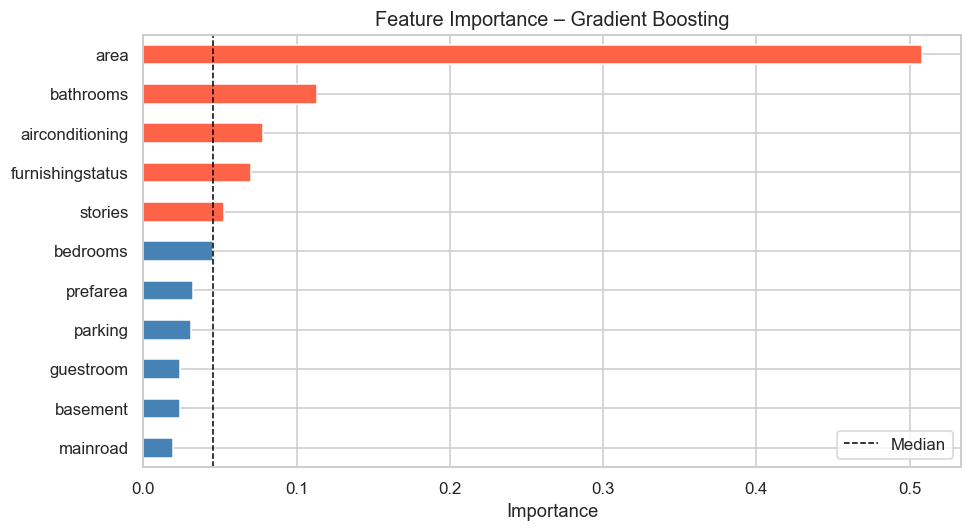

area                0.5084
bathrooms           0.1134
airconditioning     0.0782
furnishingstatus    0.0702
stories             0.0525
bedrooms            0.0456
prefarea            0.0327
parking             0.0313
guestroom           0.0243
basement            0.0242
mainroad            0.0192


In [45]:
# Feature Importance
importances = pd.Series(
    best_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
colors_fi = ['tomato' if v > importances.median() else 'steelblue' for v in importances]
importances.plot(kind='barh', color=colors_fi)
plt.title(f'Feature Importance – {best_name}', fontsize=13)
plt.xlabel('Importance')
plt.axvline(importances.median(), color='black', linestyle='--', linewidth=1, label='Median')
plt.legend()
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False).round(4).to_string())

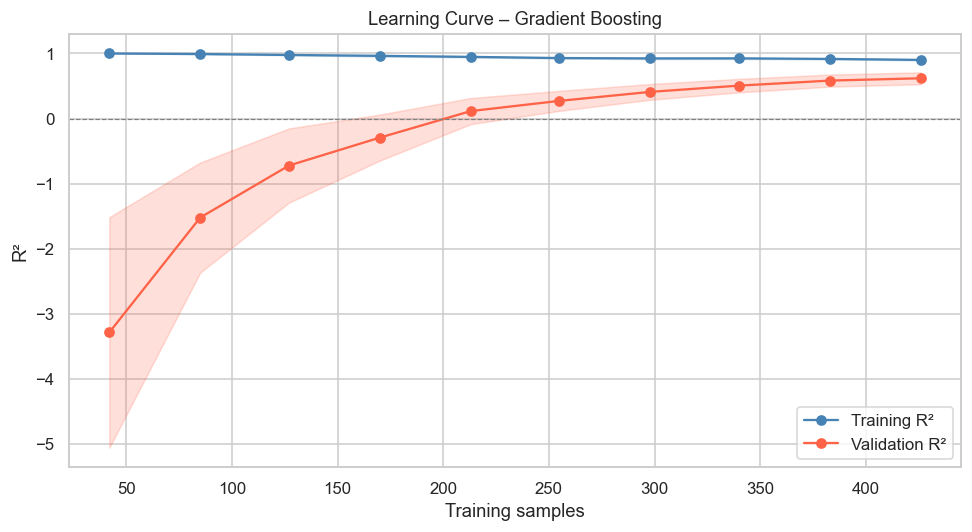

In [48]:
# Learning curve (training vs. validation error over data size)
from sklearn.model_selection import learning_curve

gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=RANDOM_STATE)
train_sizes, train_scores, val_scores = learning_curve(
    gb, X, y,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training R²', color='steelblue')
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.2, color='steelblue')
plt.plot(train_sizes, val_mean, 'o-', label='Validation R²', color='tomato')
plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.2, color='tomato')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.xlabel('Training samples')
plt.ylabel('R²')
plt.title('Learning Curve – Gradient Boosting')
plt.legend()
plt.tight_layout()
plt.show()

## 7 · Summary

| Step | Result |
|---|---|
| Dataset | 545 houses, 12 features, no missing values |
| Removed Feature | `hotwaterheating` – quasi-constant, correlation ≈ 0 |
| Outlier Removal | IQR on `area` – few extreme values |
| Encoding | Binary (yes/no → 0/1), Ordinal (furnishing) |
| Target Transformation | log1p(price) – improves linearity |
| Best Model | **Gradient Boosting** (highest R², lowest MAE) |
| Most Important Features | `area`, `bathrooms`, `airconditioning`, `stories` |